In [2]:
import os, sys
os.chdir('..')

In [3]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

import scipy.io as sio

%load_ext autoreload
%autoreload 2

sys.path.append('.')
from data_1d_test.spectral_analysis import load_maps, spectral_analysis, convert_raw_data
from toroidal_coordinates.compute_coord import visualize_tor_coords_x_traj, interp_arr, plot_toroidal_coordinates
from toroidal_coordinates.Gardner_toroidal import Gardner_coord, Gardner_persistence
from ripser import ripser# type: ignore
from constants import WEN_DATA_PATH, WEN_DATA_FIG_PATH

import math
from toroidal_coordinates.toroidal_lifting import toroidal_lifting_distance_upgrade
from affine_transform.get_transform_mat import *
from affine_transform.score_mismatch import *
from figures.plot_persistence_diagram import *

import matplotlib as mpl
import matplotlib.ticker as mticker


In [4]:
def find_large_differences(data, threshold):
    """
    Finds indices where consecutive values in a list differ by more than a threshold.

    Args:
      data: A list of numerical values.
      threshold: The minimum difference between consecutive values.

    Returns:
      A list of indices where the difference between consecutive values
      is greater than the threshold.
    """
    indices = []
    for i in range(len(data) - 1):
        if abs(data[i+1] - data[i]) > threshold:
            indices.append(i)
    return indices

In [121]:
def plot_toroidal_coordinates_oneD(xx: np.ndarray, yy: np.ndarray, coords:np.ndarray, times: np.ndarray, 
                              **kwargs) -> None:
    """
    Visualizes toroidal coordinates. 
    Differs from the previous plotting functions by (1) uses "plasma" colormap and (2) uses the original coordinates instead of cosine values.

    Args:
        xx (np.ndarray): X-coordinates of simulated trajectory.
        yy (np.ndarray): Y-coordinates of simulated trajectory.
        coords (np.ndarray): Array of toroidal coordinates.
        times (np.ndarray): Array of time values.
        aspect_equal (bool): Whether to set the aspect ratio to be equal.
    """
    
   
    xx = interp_arr(xx, coords.shape[0])
    yy = interp_arr(yy, coords.shape[0])
    
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    

    coords_color = [coords[times, 0], coords[times,1]]

    sc0 = ax[0].scatter(xx[times], yy[times], c=coords_color[0], cmap='plasma', **kwargs)
    ax[0].set_xticks([0, 100, 200, 300])
    ax[0].tick_params(axis = "both", which = "major", labelsize = 25)
    ax[0].set_xlabel("Position (cm)", fontsize = 30)
    ax[0].set_ylabel("Time (s)", fontsize = 30)
    #ax[0].set_yticks([])


    sc1 = ax[1].scatter(xx[times], yy[times], c=coords_color[1], cmap='plasma', **kwargs)
    ax[1].set_xticks([0, 100, 200, 300])
    ax[1].tick_params(axis = "both", which = "major", labelsize = 25)
    ax[1].set_xlabel("Position (cm)", fontsize = 30)
    ax[1].set_ylabel("Time (s)", fontsize = 30)
    #ax[1].set_yticks([])

    
    pos = ax[1].get_position()
    
    # Compute colorbar dimensions:
    # Width: 1/3 of the scatter plot width.
    width_ax = pos.width
    width_cbar = width_ax * (1/10)
    # Height: 80% of scatter plot height.
    height_ax = pos.height
    height_cbar = height_ax * 0.95
    # Horizontal pad between ax[1] and colorbar.
    pad = 0.02  
    x_cbar = pos.x1 + pad
    y_cbar = pos.y0 + (height_ax - height_cbar) / 2

    # Add a new axis for the colorbar at the computed position.
    cax = fig.add_axes([x_cbar, y_cbar, width_cbar, height_cbar]) # type: ignore
   
    cbar = fig.colorbar(mpl.cm.ScalarMappable(norm = mpl.colors.Normalize(vmin = 0, vmax = 2 * math.pi), cmap = "plasma"), 
                        cax=cax, ticks=np.arange(0, 2*math.pi+0.001, math.pi), format=mticker.FixedFormatter(['0', r'$\pi$', r'$2\pi$']))
    
    cbar.set_ticks(np.arange(0, 2*math.pi+0.001, math.pi))
    cbar.ax.tick_params(labelsize=25)

## Load data 
This code is provided by https://github.com/GiocomoLab/mec-rapid-learning/tree/main

In [5]:
PATH = WEN_DATA_PATH   # Change `ROOT_PATH.py``
fname =  'N2_200203_buildup_track' # 'N2_200204_buildup_track'

mat_data = sio.loadmat(os.path.join(PATH, fname + '.mat'))

mat_data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'all_maps', 'lickt', 'lickx', 'post', 'posx', 'trial_starts', 'clu_ids', 'sp'])

see the following for dictionary keys https://data.mendeley.com/datasets/rgtk6jygjc/1

In [6]:
mat_data['posx'].shape, mat_data['post'].shape, mat_data['all_maps'].shape

((209275, 1), (209275, 1), (201, 619, 160))

In [7]:
maps_data = convert_raw_data(mat_data, fname)
N = maps_data.num_neurons
ntrials = maps_data.num_trials
L = maps_data.num_spatial_bins
zmaps = maps_data.z_scored_maps
trial_starts = maps_data.trial_starts

results = spectral_analysis(maps_data)
f_modules = results.frequency_modules
phi_modules = results.phase_modules
grid_cell_idxs_modules = results.grid_cell_idxs_modules
L = results.spatial_bins
trial_starts = results.trial_starts
spectrograms = results.spectrograms

201 cells, 619 trials, 160 spatial bins
Identified 5 candidate modules


In [8]:
mat_data['all_maps'].shape

(201, 619, 160)

In [9]:
grid_cell_idxs_modules

[array([34, 36, 40, 41, 42, 44, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56,
        57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 69, 70, 71, 72, 74, 76,
        77, 79, 80, 81, 82, 83, 86, 91, 92, 96]),
 array([ 39,  68,  73,  78,  84,  85,  88,  93,  95, 102, 104, 108, 111,
        113, 114, 115, 116, 119, 120, 121, 122, 123, 128, 130, 132, 135,
        136, 138, 144, 145, 157]),
 array([ 99, 100, 103, 105, 107, 110, 118, 125, 126, 127, 129, 133]),
 array([137, 140, 142, 147, 148, 149, 151, 152, 154, 155, 156, 158, 159,
        160, 164, 166, 171, 174, 190]),
 array([169, 170, 175, 176, 177, 178, 179, 180, 181, 182, 184, 185, 186,
        187, 188, 189, 193, 194, 196, 197, 199])]

In [10]:
len(grid_cell_idxs_modules[0])

44

Here, spectral analysis is used to cluster the grid cells into distinct modules.


(44, 99040)


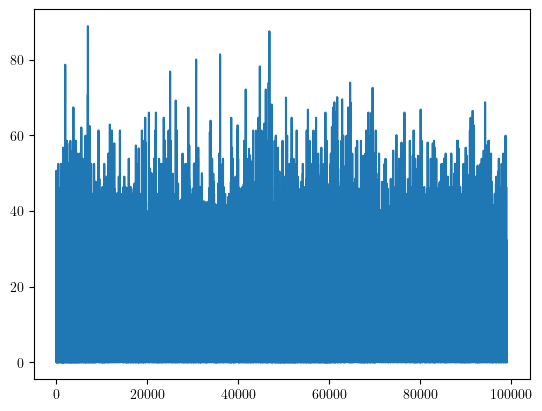

In [11]:
m1 = mat_data['all_maps'][grid_cell_idxs_modules[0]]
all_m1 = np.reshape(m1, (m1.shape[0], m1.shape[1] * m1.shape[2]))
print(all_m1.shape)
plt.plot(all_m1[0])


# Path reconstruction

In [ ]:
# Before computing the toroidal coordinates,let's check the persistence diagrams

persistence = Gardner_persistence(all_m1.T, maxdim = 1)

PD0 = persistence['dgms'][0]
PD1 = persistence['dgms'][1]
#PD2 = persistence['dgms'][2]

/home/hyoon/GridCellDecoding/toroidal_coordinates/Gardner_toroidal.py:62: RuntimeWarning: divide by zero encountered in log
  d = -np.log(d)


In [ ]:
# np.savez('data_1d_test/' + fname + '/persistence_diagrams.npz', 
#          PD0=PD0, 
#          PD1=PD1,
#          PD2=PD2)

In [12]:
pd_file = np.load('data_1d_test/' + fname + '/persistence_diagrams.npz', allow_pickle=True)
PD0 = pd_file['PD0']
PD1 = pd_file['PD1']
PD2 = pd_file['PD2']

(-1.5994862556457519, 18.154169001579284)

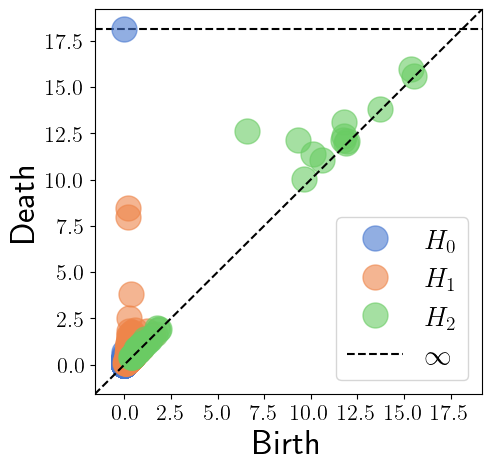

In [13]:
plot_persistence_diagram([PD0, PD1, PD2], 
                         #savefig ='data_1d_test/' + fname + '/persistence_diagrams.pdf'
                         )

(44, 99040)


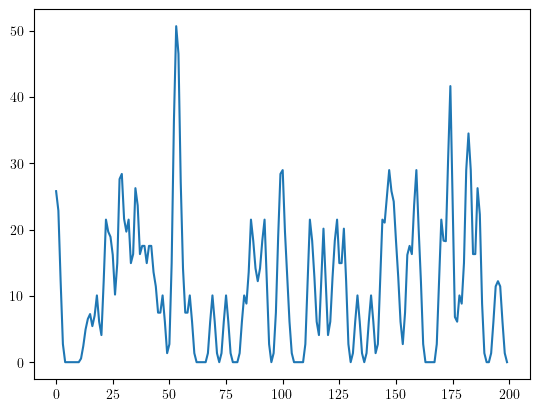

In [14]:
print(all_m1.shape)
plt.plot(all_m1[0,:200])

In [15]:
# get toroidal coordinates
coords, _, _, _ = Gardner_coord(all_m1.T)

/home/hyoon/GridCellDecoding/toroidal_coordinates/Gardner_toroidal.py:119: RuntimeWarning: divide by zero encountered in log
  d = -np.log(d)


Note that this experiment only has 44 clean grid cells, so we seem to be missing a number of grid cells that would allow us to recover the full toroidal structure

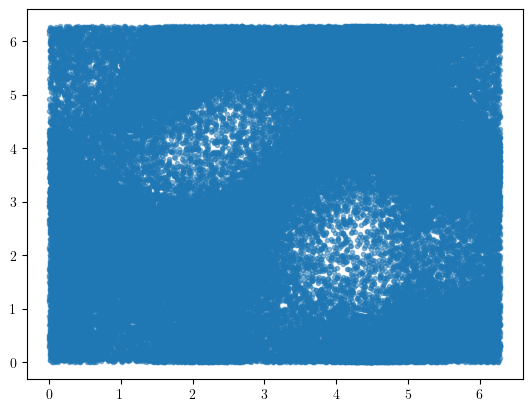

In [16]:
plt.figure()
plt.scatter(coords[:, 0], coords[:, 1], marker='.', alpha=0.5)
plt.show()

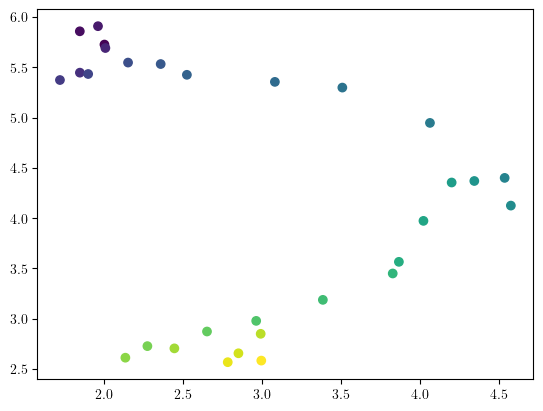

In [17]:
plt.figure()
subsection_start, subsection_end = 0, 30
color = plt.cm.viridis(np.linspace(0, 1, 30))
plt.scatter(coords[subsection_start:subsection_end,0], coords[subsection_start:subsection_end,1], marker='o', color=color)
plt.show()

In [18]:
# compute the lifted path 
lifted = toroidal_lifting_distance_upgrade(coords)
lifted.shape

4.274645671705962


(98784, 2)

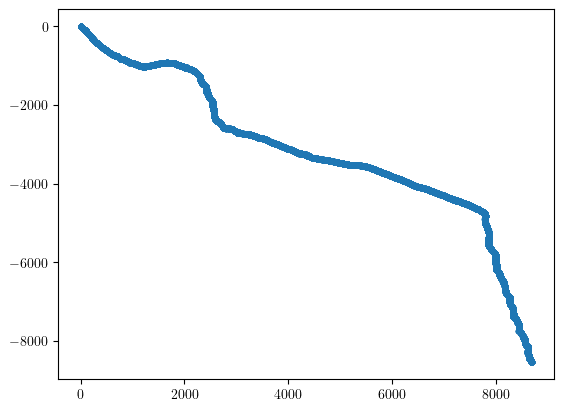

In [19]:
plt.figure()
plt.plot(lifted[:, 0], lifted[:, 1], marker='.')
plt.show()

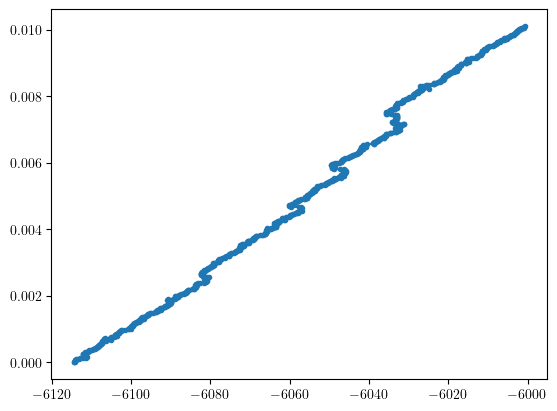

In [20]:

from sklearn.decomposition import PCA

pca = PCA(n_components=1)
proj_lifted = pca.fit_transform(lifted)

time_path = np.linspace(0, 1, proj_lifted.shape[0])
time_path = np.concatenate((proj_lifted, time_path[:, np.newaxis]), axis=1)

plt.figure()
start, end = 0, 1000
plt.plot(time_path[start:end, 0], time_path[start:end, 1], marker='.')
plt.show()

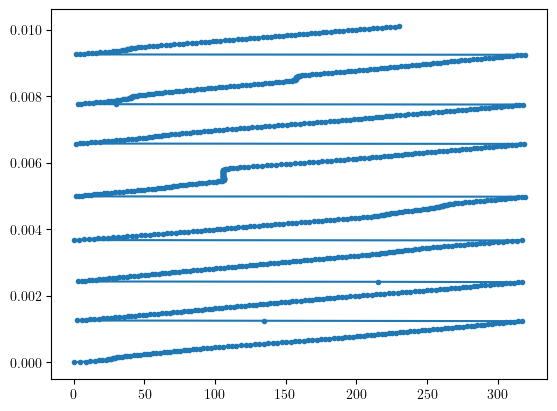

In [21]:
position = mat_data['posx'][:, 0]
position = interp_arr(position, lifted.shape[0])
start, end = 0, 1000

time_path = np.concatenate((position[:, np.newaxis], np.linspace(0, 1, position.shape[0])[:, np.newaxis]), axis=1)
plt.figure()
plt.plot(time_path[start:end, 0], time_path[start:end, 1], marker='.')
plt.show()

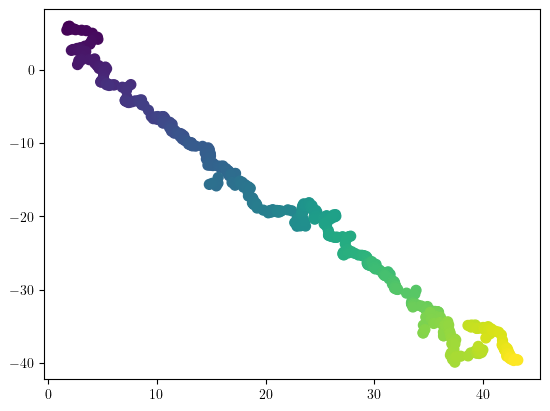

In [22]:
#plot lifted path

colors = plt.cm.viridis(np.linspace(0, 1, 514))

plt.figure()
plt.scatter(lifted[0:514, 0], lifted[0:514, 1], marker='.', color = colors, s = 200)
plt.show()

# Analysis by segment

In [25]:
# Identify line segments in data
position = mat_data['posx'][:, 0]
position = interp_arr(position, lifted.shape[0])

# identify the index where a jump occurs
jump_idx = find_large_differences(list(position), 20)
jump_idx.insert(0, 0)
print(len(jump_idx))

# times 
post = mat_data["post"][:,0] # time bin for each observation. I think in seconds 
position_time_interp = interp_arr(post, lifted.shape[0])

870


In [152]:
# specify a segment
segment_num = 48
start, end = jump_idx[segment_num]+1, jump_idx[segment_num + 1]

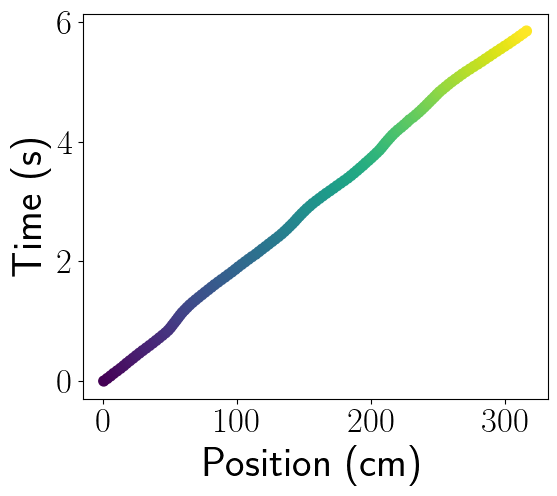

In [153]:
# plot true position for a specific time window

time_path = np.concatenate((position[:, np.newaxis], position_time_interp[:, np.newaxis]), axis=1)
traj_segment = time_path[start:end, :]
traj_segment[:,1] = traj_segment[:,1] - np.min(traj_segment[:,1])

colors = plt.cm.viridis(np.linspace(0, 1, end-start))
plt.figure(figsize = (6, 5))
plt.scatter(traj_segment[:, 0], traj_segment[:, 1], marker='.', color = colors, s = 200)
plt.xticks([0, 100, 200, 300],)
plt.xlabel("Position (cm)", fontsize = 30)
plt.ylabel("Time (s)", fontsize = 30) # I think this is in seconds 

plt.tick_params(axis='both', which='major', labelsize=25)
#plt.savefig("data_1d_test/" + fname + "/segment_" + str(segment_num) + "_original_trajectory.pdf", transparent = True, bbox_inches = "tight")
plt.show()

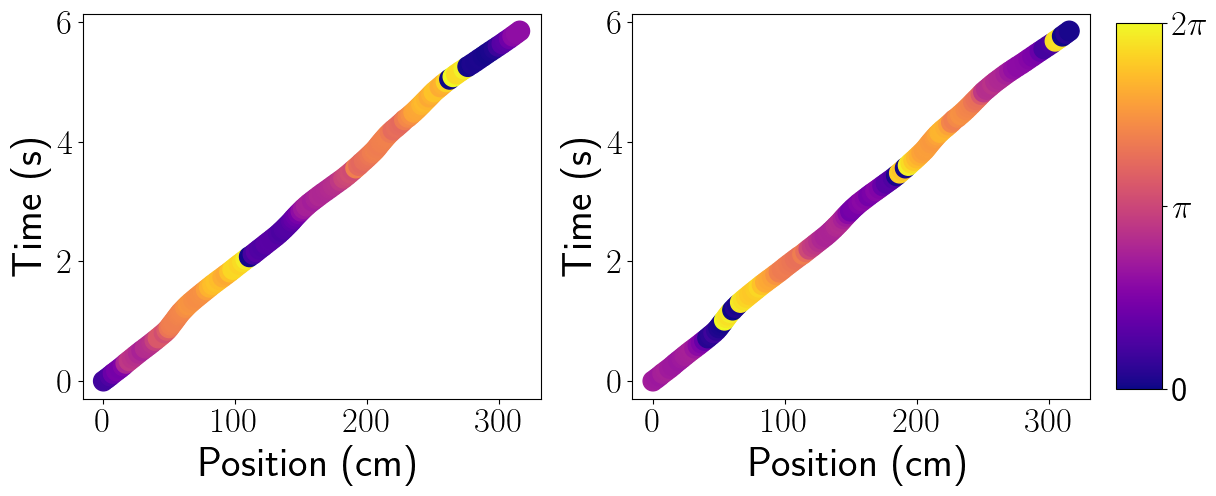

In [154]:
# plot the toroidal coordiantes for the corresponding segment
xx = time_path[:, 0]
yy = time_path[:, 1]
times = np.arange(start, end, 1)

plot_toroidal_coordinates_oneD(xx, yy, coords, times,  s = 200)
#plt.savefig("data_1d_test/" + fname + "/segment_" + str(segment_num) + "_toroidal_coordinates.pdf",  transparent = True, bbox_inches = "tight")
plt.show()

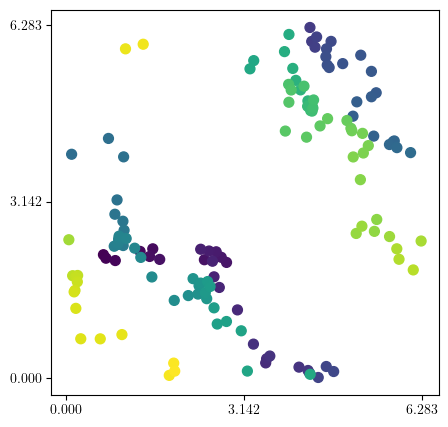

In [162]:
# plot the path on the square torus
subsection_colors = plt.cm.viridis(np.linspace(0, 1, end-start))
coords_segment = coords[start:end, :]

plt.figure(figsize = (5,5))
plt.scatter(coords_segment[:, 0], coords_segment[:, 1], marker='.', s = 200, color =subsection_colors)
plt.xticks([0, math.pi, 2*math.pi]) #, [0, "π", "2π"], fontsize = 20)
plt.yticks([0, math.pi, 2*math.pi])#, [0, "π", "2π"], fontsize = 20)


#ticks=np.arange(0, 2*math.pi+0.001, math.pi), format=mticker.FixedFormatter(['0', r'$\pi$', r'$2\pi$']))
#plt.savefig("data_1d_test/" + fname + "/segment_" + str(segment_num) + "_path_on_torus.pdf", transparent = True, bbox_inches = "tight")
plt.show()

1.3906636157105317


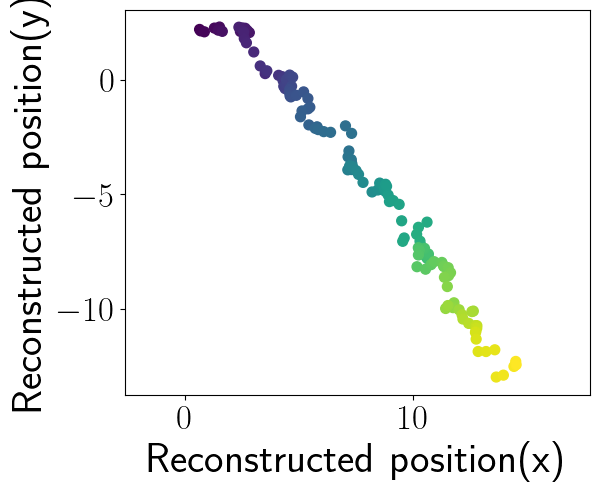

In [ ]:
lifted_segment = toroidal_lifting_distance_upgrade(coords_segment)

# plot lifted path
colors = plt.cm.viridis(np.linspace(0, 1, end-start))

plt.figure(figsize = (6,5))
plt.scatter(lifted_segment[:, 0], lifted_segment[:, 1], marker='.', color = colors, s = 200)
plt.tick_params(axis='both', which='major', labelsize=25)
plt.axis("equal")
plt.xlabel("Reconstructed position(x)", fontsize = 30)
plt.ylabel("Reconstructed position(y)", fontsize = 30)
#plt.savefig("data_1d_test/" + fname + "/segment_" + str(segment_num) + "_lifted_path.pdf", transparent = True, bbox_inches = "tight")
plt.show()

In [31]:
matrix = get_transform_mat(lifted_segment, traj_segment)
transformed_path = apply_transform_mat(lifted_segment, matrix)
segment_error = score_mismatch(transformed_path, traj_segment)
print("segment error: ", segment_error)

segment error:  0.01688351551978474


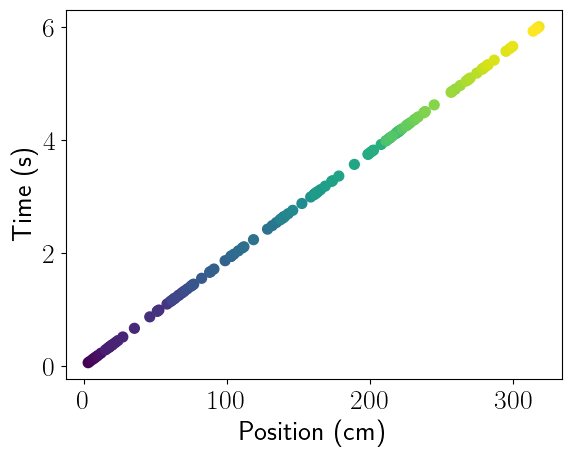

In [32]:
# plot transformed path
plt.figure()
plt.scatter(transformed_path[:,0], transformed_path[:,1], marker='.', color = colors, s = 200)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.xlabel("Position (cm)", fontsize = 20)
plt.ylabel("Time (s)", fontsize = 20)
#plt.title("Reconstructed path, transformed", fontsize = 25)
plt.show()

# Lift all segments, compute the reconstruction error

In [33]:
n_segments = len(jump_idx)-1
reconstruction_errors = dict() 
modified_errors = dict()
large_errors_index = []
small_errors_index = []

In [34]:
for segment_num in range(n_segments):
    start, end = jump_idx[segment_num]+1, jump_idx[segment_num + 1]

    # check if this is a valid segment
    if end - start < 100:
        print(f"Segment {segment_num} is too short, skipping.")
        continue
    else:

        # specify the trajectory segment
        traj_segment = time_path[start:end, :]

        # perform lifting on the segment
        coords_segment = coords[start:end, :]
        lifted_segment = toroidal_lifting_distance_upgrade(coords_segment)

        # compute error
        matrix = get_transform_mat(lifted_segment, traj_segment)
        transformed_path = apply_transform_mat(lifted_segment, matrix)
        
        segment_error = score_mismatch(transformed_path, traj_segment)

        # a modified error: just comparing the x-coordinates. Should be similar to the original error
        traj_length = traj_segment[-1,0] - traj_segment[0,0]
        modified_error = np.mean([math.sqrt((transformed_path[i,0] - traj_segment[i,0])**2) for i in range(transformed_path.shape[0])])/traj_length

        reconstruction_errors[segment_num] = segment_error 
        modified_errors[segment_num] = modified_error

        if segment_error > 0.5 or modified_error > 0.4:
            large_errors_index.append(segment_num)
        if segment_error < 0.02:
            small_errors_index.append(segment_num)
      
end

2.3771237089377273
Segment 1 is too short, skipping.
0.9508406442079607
Segment 3 is too short, skipping.
0.837743308678728
3.1185395751849185
1.598008730847458
4.117566039026473
Segment 8 is too short, skipping.
4.017035074111599
1.6042919161546376
Segment 11 is too short, skipping.
0.6178318229274424
Segment 13 is too short, skipping.
4.368893451313656
4.098716483104933
Segment 16 is too short, skipping.
3.903937738582367
Segment 18 is too short, skipping.
4.2306633745557045
Segment 20 is too short, skipping.
0.869159235214626
3.313318319707485
4.048451000647497
4.293495227627501
Segment 25 is too short, skipping.
1.019955682586936
1.491194580625405
2.006415775814131
Segment 29 is too short, skipping.
4.287212042320321
4.375176636620835
4.130132409640831
Segment 33 is too short, skipping.
2.1572122231864412
Segment 35 is too short, skipping.
4.1426987802551904
0.6241150082346221
2.8923449041264533
3.2819023931715874
Segment 40 is too short, skipping.
3.790840403053134
1.2461503536454

98764

In [40]:
print("number of valid segments: ", len(reconstruction_errors))
print("mean error: ", np.mean(list(reconstruction_errors.values())))
print("median error: ", np.median(list(reconstruction_errors.values())))

number of valid segments:  617
mean error:  0.05943382656613244
median error:  0.0367155566956276


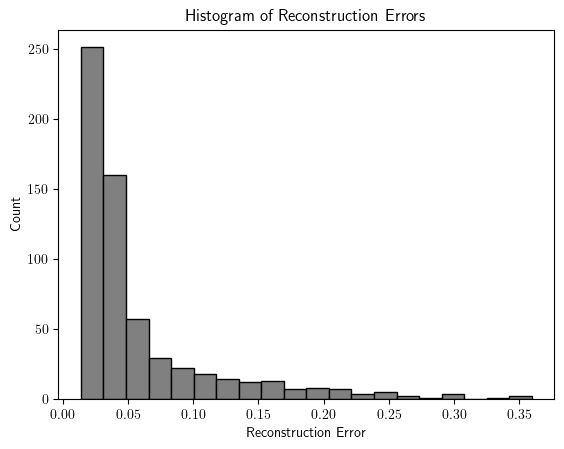

In [42]:
plt.hist(reconstruction_errors.values(), bins = 20, edgecolor='black', color = "grey")
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title("Histogram of Reconstruction Errors")
#plt.savefig("data_1d_test/" + fname + "/reconstruction_errors_histogram.pdf", transparent = True, bbox_inches = "tight")
plt.show()

# SI figures -- example segments

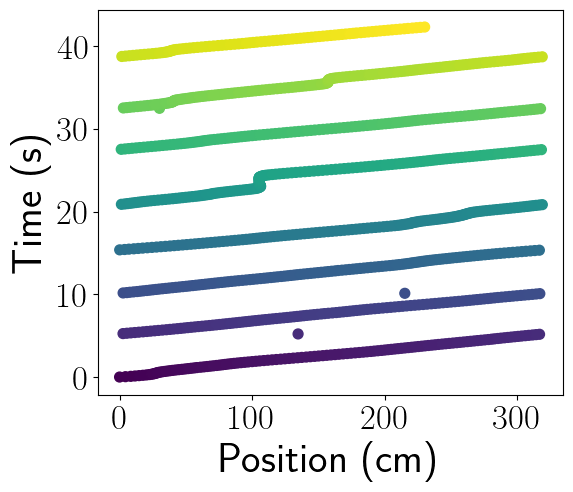

In [43]:
# plot the entire trajectory, including the transport 
start, end = 0, 1000


time_path = np.concatenate((position[:, np.newaxis], position_time_interp[:, np.newaxis]), axis=1)
traj_segment = time_path[start:end, :]



time_path = np.concatenate((position[:, np.newaxis], position_time_interp[:, np.newaxis]), axis=1)
traj_segment = time_path[start:end, :]
traj_segment[:,1] = traj_segment[:,1] - np.min(traj_segment[:,1])

colors = plt.cm.viridis(np.linspace(0, 1, end-start))
plt.figure(figsize = (6, 5))
plt.scatter(traj_segment[:, 0], traj_segment[:, 1], marker='.', color = colors, s = 200)
plt.xticks([0, 100, 200, 300],)
plt.xlabel("Position (cm)", fontsize = 30)
plt.ylabel("Time (s)", fontsize = 30) # I think this is in seconds 

plt.tick_params(axis='both', which='major', labelsize=25)
#plt.savefig("data_1d_test/" + fname + "/original_trajectory.pdf", transparent = True, bbox_inches = "tight")
plt.show()

Pick a few segments with high, medium, and low reconstruction errors.

plot the original trajectory, the toroidal coordinates, the lifted path, lifted path (transformed)

In [92]:
error_large = []
error_medium = []
error_small = []

for (k,v) in reconstruction_errors.items():

    if v > 0.28 and v < 0.32:
        error_large.append(k)
    if v > 0.145 and v < 0.155: 
        error_medium.append(k)
    if v < 0.015:
        error_small.append(k)

In [93]:
error_medium


[15, 133, 200, 324, 666, 817]

In [94]:
error_small

[252, 640, 650]

In [95]:
error_large

[285, 405, 675, 676]

In [151]:
print("Small error for segment 252:", reconstruction_errors[252])
print("Medium error for segment 15:", reconstruction_errors[15])
print("Large error for segment 285:", reconstruction_errors[285])

Small error for segment 252: 0.01389740680219449
Medium error for segment 15: 0.1468980671382641
Large error for segment 285: 0.29545348171782665


In [181]:
# specify a segment
segment_num = 285
start, end = jump_idx[segment_num]+1, jump_idx[segment_num + 1]

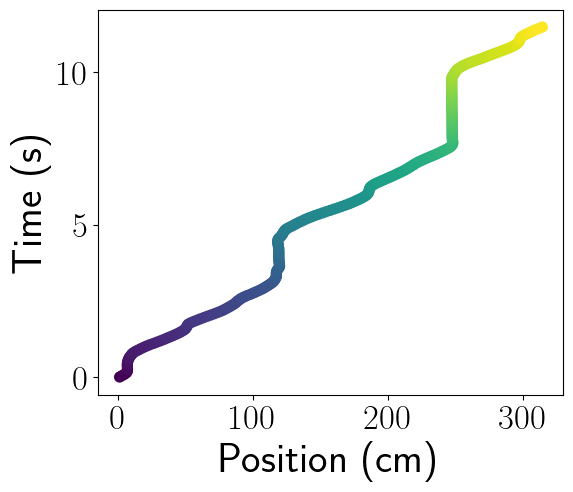

In [182]:
# plot true position for a specific time window

time_path = np.concatenate((position[:, np.newaxis], position_time_interp[:, np.newaxis]), axis=1)
traj_segment = time_path[start:end, :]
traj_segment[:,1] = traj_segment[:,1] - np.min(traj_segment[:,1])

colors = plt.cm.viridis(np.linspace(0, 1, end-start))
plt.figure(figsize = (6, 5))
plt.scatter(traj_segment[:, 0], traj_segment[:, 1], marker='.', color = colors, s = 200)
plt.xticks([0, 100, 200, 300],)
plt.xlabel("Position (cm)", fontsize = 30)
plt.ylabel("Time (s)", fontsize = 30) # I think this is in seconds 

plt.tick_params(axis='both', which='major', labelsize=25)
plt.savefig("data_1d_test/" + fname + "/segment_" + str(segment_num) + "_original_trajectory.pdf", transparent = True, bbox_inches = "tight")
plt.show()

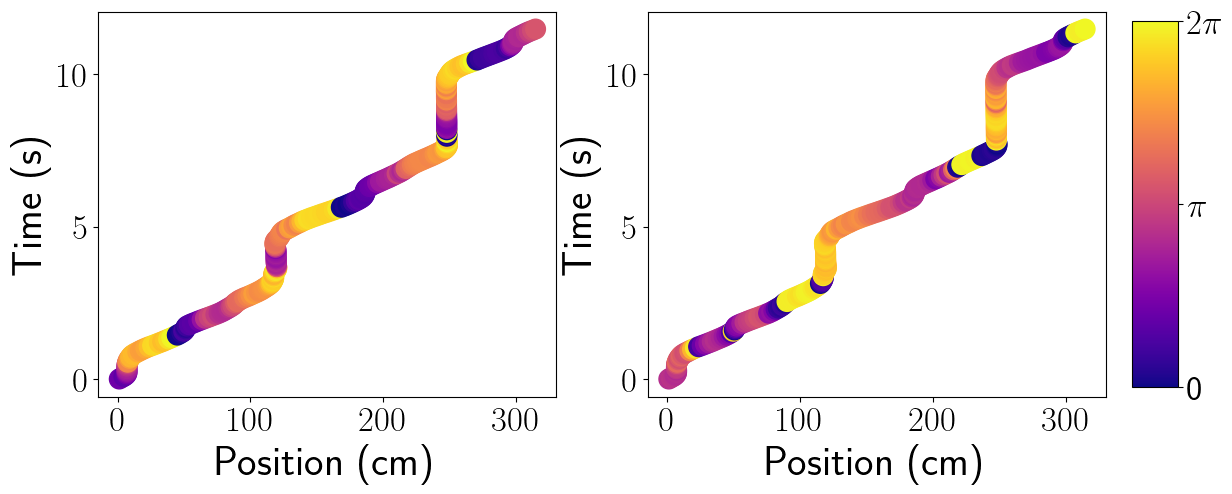

In [183]:
# plot the toroidal coordiantes for the corresponding segment
xx = time_path[:, 0]
yy = time_path[:, 1]
times = np.arange(start, end, 1)

plot_toroidal_coordinates_oneD(xx, yy, coords, times,  s = 200)
plt.savefig("data_1d_test/" + fname + "/segment_" + str(segment_num) + "_toroidal_coordinates.pdf",  transparent = True, bbox_inches = "tight")
plt.show()

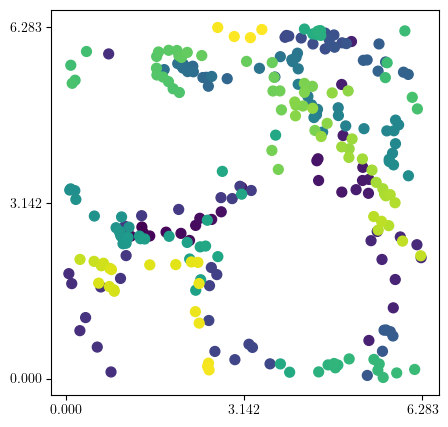

In [184]:
# plot the path on the square torus
subsection_colors = plt.cm.viridis(np.linspace(0, 1, end-start))
coords_segment = coords[start:end, :]

plt.figure(figsize = (5,5))
plt.scatter(coords_segment[:, 0], coords_segment[:, 1], marker='.', s = 200, color =subsection_colors)
plt.xticks([0, math.pi, 2*math.pi])#, [0, "π", "2π"], fontsize = 20)
plt.yticks([0, math.pi, 2*math.pi])#, [0, "π", "2π"], fontsize = 20)
plt.savefig("data_1d_test/" + fname + "/segment_" + str(segment_num) + "_path_on_torus.pdf", transparent = True, bbox_inches = "tight")
plt.show()

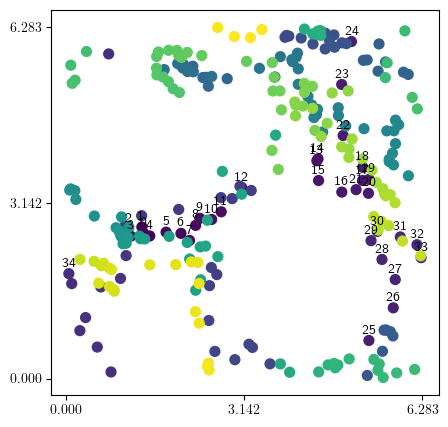

In [185]:
# plot the path on the square torus
subsection_colors = plt.cm.viridis(np.linspace(0, 1, end-start))
coords_segment = coords[start:end, :]

plt.figure(figsize = (5,5))
plt.scatter(coords_segment[:, 0], coords_segment[:, 1], marker='.', s = 200, color =subsection_colors)
labels = np.arange(0, end-start)
for i, label in enumerate(labels):
    if label <35:
        plt.annotate(label, (coords_segment[i,0], coords_segment[i,1]), textcoords="offset points", xytext=(0,5), ha='center')


plt.xticks([0, math.pi, 2*math.pi])#, [0, "π", "2π"], fontsize = 20)
plt.yticks([0, math.pi, 2*math.pi])#, [0, "π", "2π"], fontsize = 20)
#plt.savefig("data_1d_test/" + fname + "/segment_" + str(segment_num) + "_path_on_torus.pdf", transparent = True, bbox_inches = "tight")
plt.show()

2.389690079552086


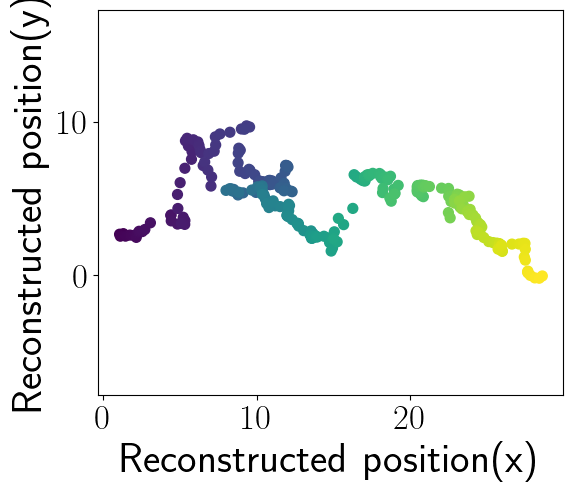

In [186]:
lifted_segment = toroidal_lifting_distance_upgrade(coords_segment)

# plot lifted path
colors = plt.cm.viridis(np.linspace(0, 1, end-start))

plt.figure(figsize = (6,5))
plt.scatter(lifted_segment[:, 0], lifted_segment[:, 1], marker='.', color = colors, s = 200)
plt.tick_params(axis='both', which='major', labelsize=25)
plt.axis("equal")
plt.xlabel("Reconstructed position(x)", fontsize = 30)
plt.ylabel("Reconstructed position(y)", fontsize = 30)
plt.savefig("data_1d_test/" + fname + "/segment_" + str(segment_num) + "_lifted_path.pdf", transparent = True, bbox_inches = "tight")
plt.show()

In [187]:
matrix = get_transform_mat(lifted_segment, traj_segment)
transformed_path = apply_transform_mat(lifted_segment, matrix)
segment_error = score_mismatch(transformed_path, traj_segment)
print("segment error: ", segment_error)

segment error:  0.2954534824311434


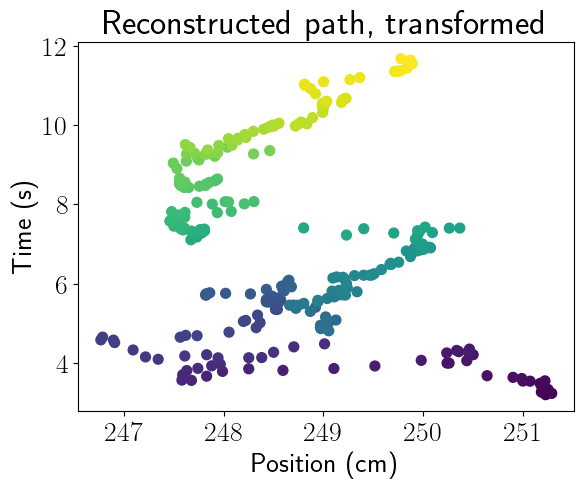

In [188]:
# plot transformed path
plt.figure()
plt.scatter(transformed_path[:,0], transformed_path[:,1], marker='.', color = colors, s = 200)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.xlabel("Position (cm)", fontsize = 20)
plt.ylabel("Time (s)", fontsize = 20)
plt.title("Reconstructed path, transformed", fontsize = 25)
plt.show()